In [49]:
import torch

# 1. 檢查 PyTorch 版本
print(f"PyTorch Version: {torch.__version__}")

# 2. 檢查 GPU 是否可用 (對應 tf.test.is_gpu_available())
is_gpu_available = torch.cuda.is_available()
print(f"GPU Available: {is_gpu_available}")

# 3. (額外建議) 如果有抓到 GPU，印出顯卡型號確認
if is_gpu_available:
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("Using CPU")

PyTorch Version: 2.9.1+cu130
GPU Available: True
Device Name: NVIDIA GeForce RTX 3090


In [50]:
# import需要的模組

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from matplotlib import pyplot as plt
import time
import joblib

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import r2_score, mean_absolute_error


In [51]:
# 讀取data

train_df = pd.read_csv('effective_data.csv')
train_df.shape

(3033, 58)

In [52]:
x_train_image_data = train_df.values[:,0:25]
x_train_image_data = np.array(x_train_image_data)
x_train_image_data = x_train_image_data.reshape(x_train_image_data.shape[0],5,5,1)

In [53]:
x_train_data = train_df.values[:,25:46]
x_train_data = np.array(x_train_data)

In [54]:
y_train_data = train_df.values[:,-12:]
y_train_data = np.array(y_train_data)

In [55]:
# 1. 建立原始資料的索引，用於精準追蹤最後 33 筆（傳統編織）的流向
indices = np.arange(len(x_train_data))

# 2. 【先切割資料】：將原始 3033 筆資料分為訓練集 (85%) 與測試集 (15%)
indices_train, indices_test, x_train_img, x_test_img, x_train, x_test, y_train, y_test = train_test_split(
    indices, x_train_image_data, x_train_data, y_train_data, test_size=0.15, random_state=8
)

# 3. 找出被隨機分配到「訓練集」中的傳統編織資料（原始索引 >= 3000）
traditional_train_mask = indices_train >= 3000
x_base = x_train[traditional_train_mask]
x_image_base = x_train_img[traditional_train_mask]
y_base = y_train[traditional_train_mask]

In [56]:
# 4. 設定擴增目標
target_size = 3500
original_total_size = len(x_train_data)
# 預計產生 467 筆，讓整體資料庫的規模達到 3500 筆的概念
num_to_generate = target_size - original_total_size 

print(f"原始資料總筆數: {original_total_size}")
print(f"切分後訓練集筆數: {len(x_train)}")
print(f"切分後測試集筆數: {len(x_test)}")
print(f"分配到訓練集的傳統編織筆數: {len(x_base)}")
print(f"預計增強產生筆數: {num_to_generate}")


原始資料總筆數: 3033
切分後訓練集筆數: 2578
切分後測試集筆數: 455
分配到訓練集的傳統編織筆數: 26
預計增強產生筆數: 467


增強完成！擴充後的訓練集最終筆數: 3045


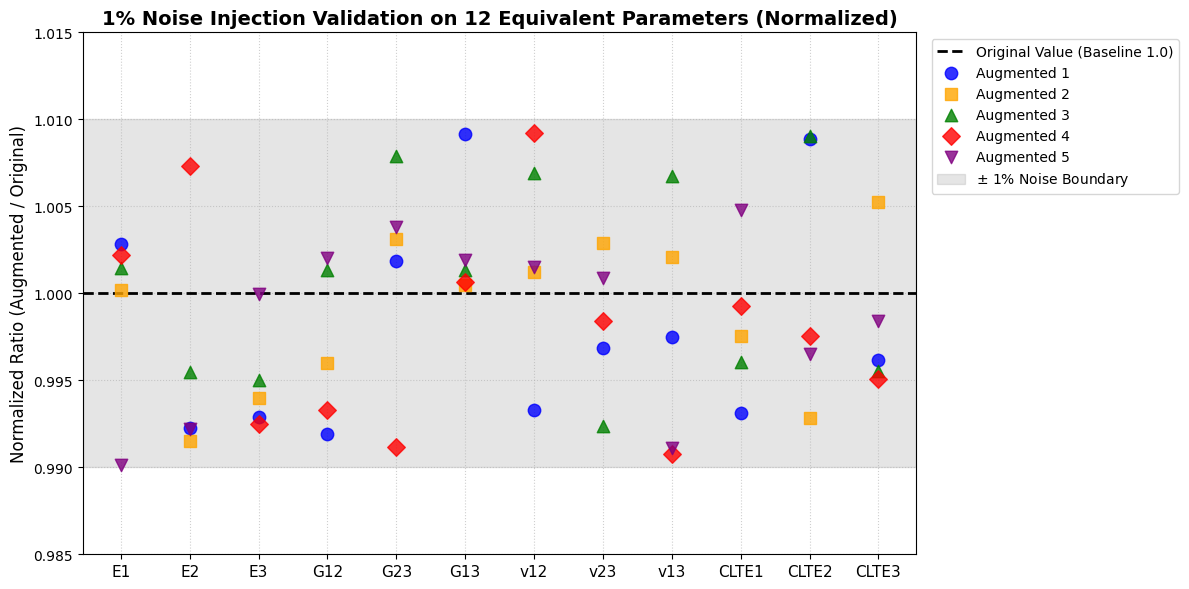

In [57]:
if num_to_generate > 0 and len(x_base) > 0:
    x_aug_list = []
    x_image_aug_list = []
    y_aug_list = []
    
    # 從「訓練集內」的傳統編織樣本進行隨機抽樣增強
    base_indices = np.random.choice(len(x_base), size=num_to_generate, replace=True)
    
    for idx in base_indices:
        x_aug = np.copy(x_base[idx])
        x_image_aug = np.copy(x_image_base[idx])
        y_aug = np.copy(y_base[idx])
        
        # 針對 12 個等效參數產生獨立的 ±1% 隨機變化噪音
        noise_ratios = np.random.uniform(-0.01, 0.01, size=len(y_aug))
        y_aug = y_aug * (1 + noise_ratios)
        
        x_aug_list.append(x_aug)
        x_image_aug_list.append(x_image_aug)
        y_aug_list.append(y_aug)
    
    # 5. 【僅增強訓練集】：將擴增的資料僅與訓練集進行合併
    x_train_expanded = np.concatenate((x_train, np.array(x_aug_list)), axis=0)
    x_train_image_expanded = np.concatenate((x_train_img, np.array(x_image_aug_list)), axis=0)
    y_train_expanded = np.concatenate((y_train, np.array(y_aug_list)), axis=0)
    
    print(f"增強完成！擴充後的訓練集最終筆數: {len(x_train_expanded)}")

    # 繪圖比較 (使用「正規化比例」來克服數值級別差異過大的問題)
    plt.figure(figsize=(12, 6))

    original_y = y_base[0]
    properties = ['E1', 'E2', 'E3', 'G12', 'G23', 'G13', 
                  'v12', 'v23', 'v13', 'CLTE1', 'CLTE2', 'CLTE3']
    x_positions = np.arange(len(properties))

    plt.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='Original Value (Baseline 1.0)')

    plot_count = 0
    colors = ['blue', 'orange', 'green', 'red', 'purple']
    markers = ['o', 's', '^', 'D', 'v']
    
    for i, base_idx in enumerate(base_indices):
        if base_idx == 0 and plot_count < 5:
            aug_y = y_aug_list[i]
            normalized_aug_y = aug_y / original_y
            
            plt.scatter(x_positions, normalized_aug_y, 
                        label=f'Augmented {plot_count+1}', 
                        color=colors[plot_count], 
                        marker=markers[plot_count],
                        s=80, alpha=0.8, zorder=5)
            plot_count += 1

    plt.axhspan(0.99, 1.01, color='gray', alpha=0.2, label='$\pm$ 1% Noise Boundary')
    plt.title('1% Noise Injection Validation on 12 Equivalent Parameters (Normalized)', fontsize=14, fontweight='bold')
    plt.xticks(x_positions, properties, fontsize=11)
    plt.ylabel('Normalized Ratio (Augmented / Original)', fontsize=12)
    plt.ylim(0.985, 1.015) 
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.show()

else:
    print("目標筆數不大於目前筆數或無傳統樣本分配至訓練集，不需擴增。")
    x_train_expanded = x_train
    x_train_image_expanded = x_train_img
    y_train_expanded = y_train

In [58]:
# 6. 【獨立縮放防洩漏 (Fit on Train only)】
# 將 X_minMax 擬合 (fit) 於增強後的訓練集，隨後分別轉換 (transform) 訓練集與測試集
X_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(x_train_expanded)
x_train_data_scaled = X_minMax.transform(x_train_expanded)
x_test_data_scaled = X_minMax.transform(x_test)

# 將 Y_minMax 擬合 (fit) 於增強後的訓練集標籤，隨後分別轉換 (transform) 訓練集與測試集標籤
Y_minMax = preprocessing.MinMaxScaler(feature_range=(0, 1)).fit(y_train_expanded)
y_train_data_scaled = Y_minMax.transform(y_train_expanded)
y_test_data_scaled = Y_minMax.transform(y_test)

In [59]:

# 儲存 Scaler 模型
joblib.dump(X_minMax, "effective_input_scaler.pkl")
joblib.dump(Y_minMax, "effective_output_scaler.pkl")

['effective_output_scaler.pkl']

In [60]:
output_title = ['E1','E2','E3','G12','G23','G13','v12','v23','v13','CTE1','CTE2','CTE3']

In [61]:
# 檢查分析label的分佈情況

y_train_data_np = np.array(train_df.values[:,-12:]).astype(float)
y_train_data_pd = pd.DataFrame(data=y_train_data_np,columns=output_title)

print(y_train_data_pd.describe())

                 E1            E2            E3           G12           G23  \
count  3.033000e+03  3.033000e+03  3.033000e+03  3.033000e+03  3.033000e+03   
mean   4.884349e+10  3.587448e+10  2.935706e+10  1.245851e+10  1.035457e+10   
std    1.357748e+10  9.488881e+09  6.962174e+09  3.058874e+09  2.850597e+09   
min    2.762200e+10  2.040000e+10  1.884700e+10  6.423300e+09  6.301300e+09   
25%    3.833100e+10  2.868100e+10  2.378200e+10  1.042000e+10  8.060500e+09   
50%    4.513500e+10  3.606000e+10  2.665300e+10  1.242300e+10  9.918100e+09   
75%    5.681400e+10  4.057700e+10  3.603000e+10  1.485500e+10  1.180000e+10   
max    9.185800e+10  6.868700e+10  4.628900e+10  2.050300e+10  1.833300e+10   

                G13          v12          v23          v13         CTE1  \
count  3.033000e+03  3033.000000  3033.000000  3033.000000  3033.000000   
mean   1.062654e+10     0.281443     0.337324     0.316281     0.000028   
std    2.913825e+09     0.091637     0.093239     0.084095     

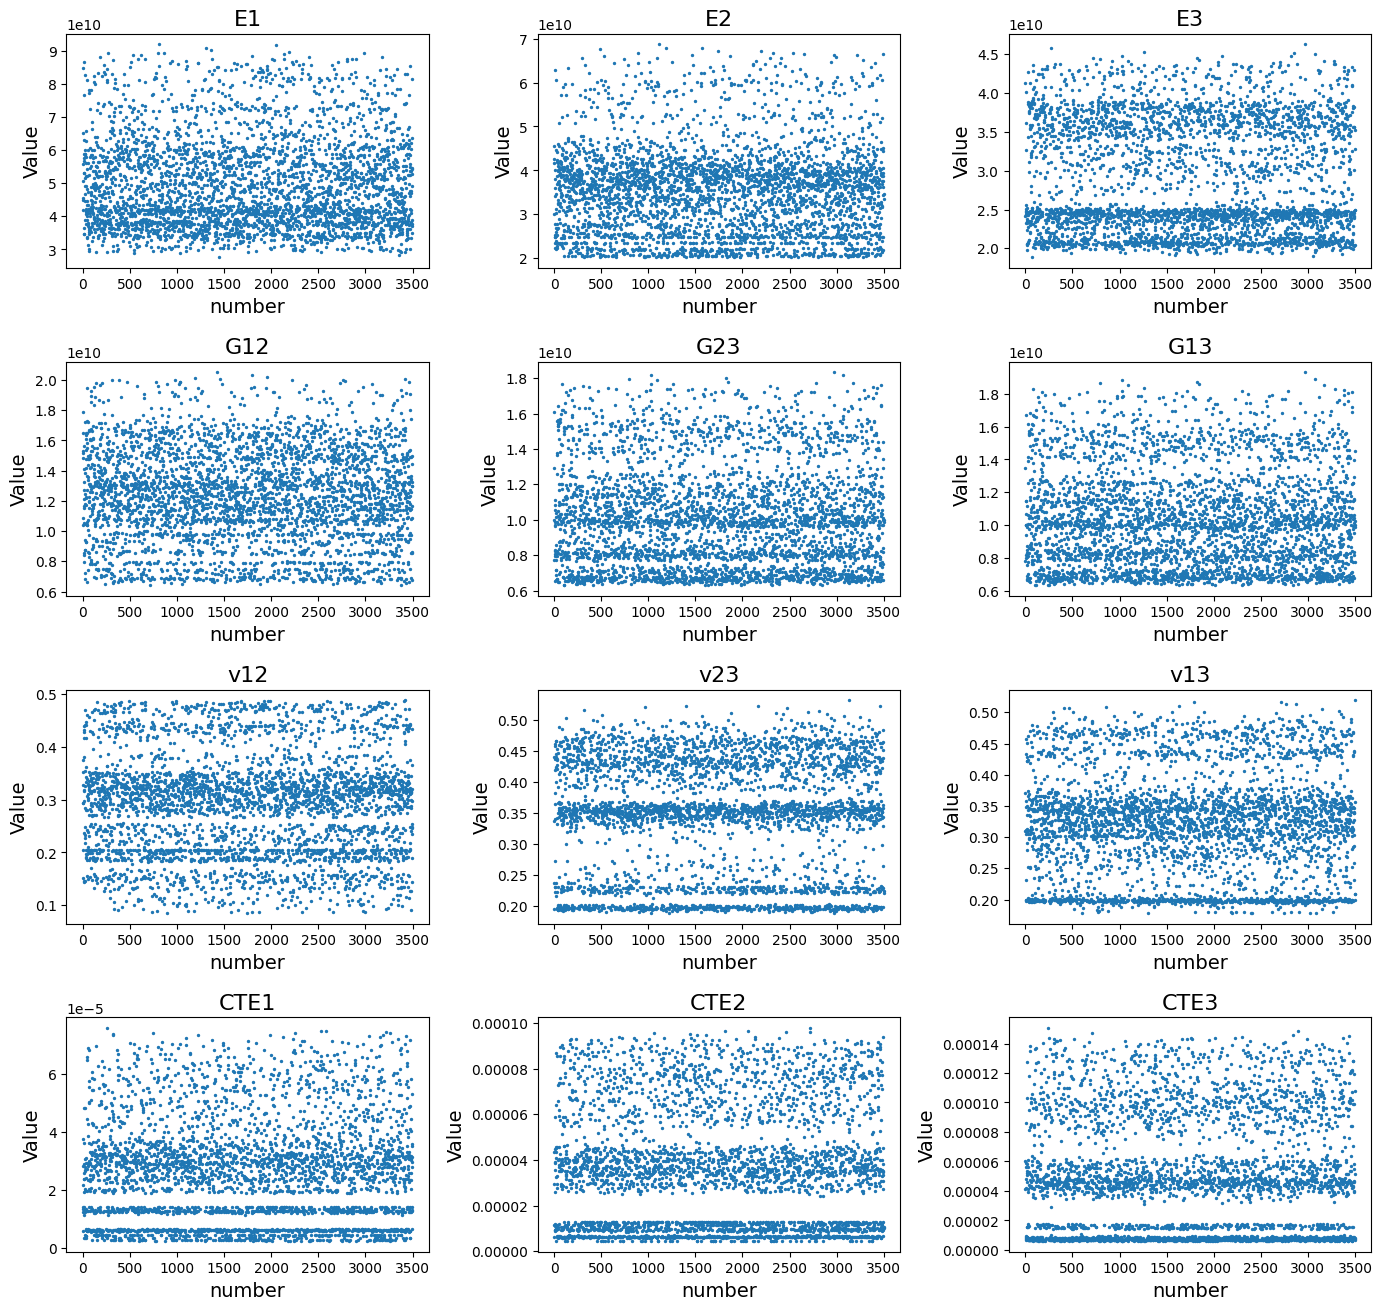

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# 新增：將增強後的訓練集與測試集合併，還原出完整的 3500 筆資料分佈
y_all_expanded = np.concatenate((y_train_expanded, y_test), axis=0)

# 將label分佈圖像化
fig, ax = plt.subplots(4, 3, figsize=(15, 14))
i = 0

# 產生一組與合併後資料長度相同的隨機索引，並據此打亂資料
shuffled_indices = np.random.permutation(len(y_all_expanded))
shuffled_y = y_all_expanded[shuffled_indices]

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        # 使用打亂後的 shuffled_y 進行繪圖
        ax[a, b].scatter(np.arange(shuffled_y.shape[0]), shuffled_y[:, i], s=2)
        ax[a, b].set_title(output_title[i], fontsize=16)
        # ax[a, b].legend(['Train', 'Validation'], fontsize=12)
        ax[a, b].set_xlabel('number', fontsize=14)
        ax[a, b].set_ylabel('Value', fontsize=14)
        # ax[a, b].grid(linewidth=0.5)
        i = i + 1

# 調整子圖間距與邊界
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.08, top=0.95, wspace=0.3, hspace=0.4)
plt.savefig("data_distribution.png", dpi=400)

plt.show()

In [63]:
x_angle_data_new = train_df.values[3000:-3,25:26]
y_data_new = train_df.values[3000:-3,-12:]

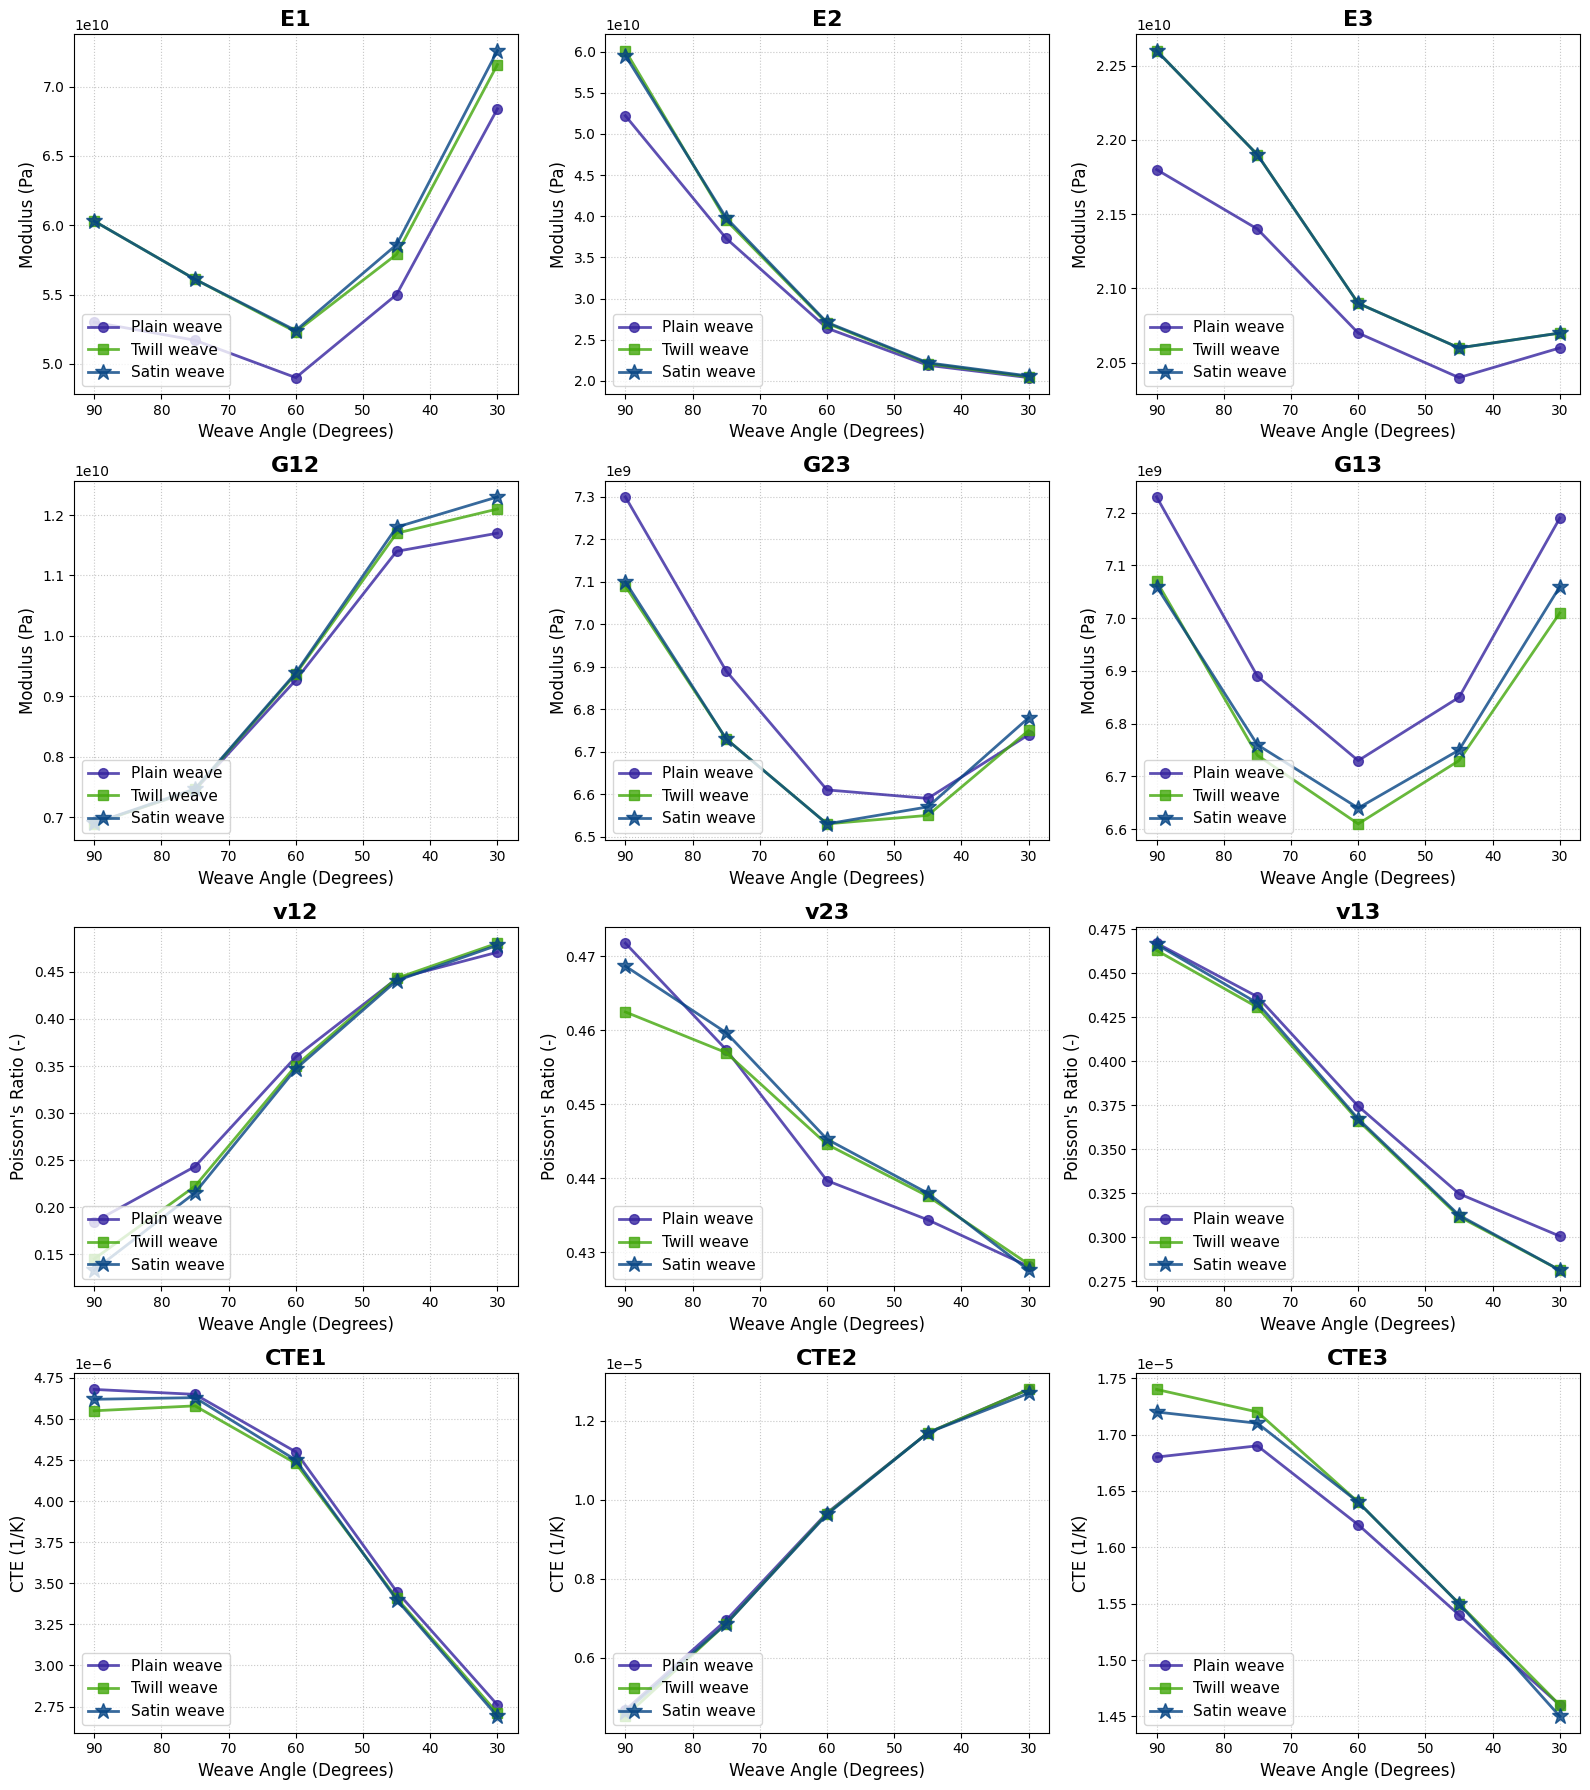

In [64]:
# 1. 取出前 15 筆資料 (針對第一組纖維與樹脂的組合)
x_subset = x_angle_data_new[-15:].flatten()
y_subset = y_data_new[-15:, :]
# x_subset = x_angle_data_new[:15].flatten()
# y_subset = y_data_new[:15, :]

# 2. 轉換角度
# 根據指示，將讀取到的 0, 15, 30, 45, 60 轉換為 90, 75, 60, 45, 30
# 轉換公式：實際角度 = 90 - 讀取角度
angles_converted = 90 - x_subset

# 3. 定義編織樣式的資料索引範圍 (每種樣式各 5 筆)
weave_styles = {
    'Plain weave': (0, 5),
    'Twill weave': (5, 10),
    'Satin weave': (10, 15)
}

# 定義 12 個等效參數的名稱，這將作為各個子圖的標題
properties = [
    'E1', 'E2', 'E3', 'G12', 'G23', 'G13', 
    'v12', 'v23', 'v13', 'CTE1', 'CTE2', 'CTE3'
]

# 4. 建立 4x3 的子圖矩陣，設定整體的畫布大小
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
axes = axes.flatten() # 將 2D 陣列攤平，方便在迴圈中透過索引呼叫

# 定義不同編織樣式的顏色與標記符號，確保列印成黑白論文時也能具備辨識度
styles_format = {
    'Plain weave': {'color': "#35239F", 'marker': 'o', 'marker_size': 7},
    'Twill weave': {'color': "#42A70B", 'marker': 's', 'marker_size': 7},
    'Satin weave': {'color': "#054483" , 'marker': '*', 'marker_size': 12}
}

# 5. 使用迴圈針對每一個等效參數繪製趨勢圖
for i in range(12):
    ax = axes[i]
    
    # 在當前子圖中，畫出三種編織樣式的線條
    for style_name, (start, end) in weave_styles.items():
        # 取出該編織樣式對應的角度與等效參數值
        style_angles = angles_converted[start:end]
        style_values = y_subset[start:end, i]
        
        ax.plot(style_angles, style_values, 
                label=style_name, 
                color=styles_format[style_name]['color'], 
                marker=styles_format[style_name]['marker'], 
                linestyle='-', 
                linewidth=2,
                markersize=styles_format[style_name]['marker_size'], 
                alpha=0.8)
    
    # 設定圖表標籤與格式
    ax.set_title(f'{properties[i]}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Weave Angle (Degrees)', fontsize=12)
    
    # 針對應變、卜瓦松比與熱膨脹係數給予不同的 Y 軸標籤
    if properties[i].startswith('E') or properties[i].startswith('G'):
        ax.set_ylabel('Modulus (Pa)', fontsize=12)
    elif properties[i].startswith('v'):
        ax.set_ylabel('Poisson\'s Ratio (-)', fontsize=12)
    else:
        ax.set_ylabel('CTE (1/K)', fontsize=12)
    
    # 反轉 X 軸，讓角度由左至右呈現 90度 遞減至 30度 的視覺邏輯
    ax.invert_xaxis()
    
    # 開啟網格線
    ax.grid(True, linestyle=':', alpha=0.7)
    
    ax.legend(loc='lower left', fontsize=11)

# 自動調整子圖之間的間距，避免文字重疊
plt.tight_layout()

# 顯示圖表
plt.show()

In [65]:
# class CompositeDualModel(nn.Module):
#     def __init__(self):
#         super().__init__()

#         # --- 1. Image Branch (圖像路徑) ---
#         self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
#         self.relu = nn.ReLU()
#         self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
#         self.dropout1 = nn.Dropout(0.2)
#         self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
#         self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
#         self.flatten = nn.Flatten()
        
#         # [修正點 1] 這裡原本是 2*2*2=8，但根據錯誤訊息，PyTorch 實際算出來是 18
#         # 所以我們直接改成 18 讓它通過
#         self.img_dense_block = nn.Sequential(
#             nn.Linear(18, 960), 
#             nn.ReLU(),
#             nn.Linear(960, 480),
#             nn.ReLU(),
#             nn.Linear(480, 240),
#             nn.ReLU(),
#             nn.Linear(240, 120),
#             nn.ReLU()
#         )

#         # --- 2. Info Branch (性質路徑) ---
#         self.info_dense_block = nn.Sequential(
#             nn.Linear(21, 64),
#             nn.ReLU(),
#             nn.Linear(64, 48),
#             nn.ReLU(),
#             nn.Linear(48, 36),
#             nn.ReLU(),
#             nn.Linear(36, 24),
#             nn.ReLU()
#         )

#         # --- 3. Combined Path (結合後路徑) ---
#         self.c_conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=2, stride=1, padding=0)
#         self.c_conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=2, stride=1, padding=1)
#         self.c_conv3 = nn.Conv2d(in_channels=16, out_channels=12, kernel_size=2, stride=1, padding=1)
        
#         # [修正點 2] 預防下一個錯誤
#         # 經過計算，PyTorch 的 padding=1 會讓尺寸稍微變大：
#         # Input 12x12 -> c_conv1(valid) -> 11x11
#         # 11x11 -> c_conv2(pad=1) -> 12x12
#         # 12x12 -> c_conv3(pad=1) -> 13x13
#         # 所以最終 Flatten 大小是：12 (channels) * 13 * 13 = 2028
#         self.final_dense_block = nn.Sequential(
#             nn.Linear(12 * 13 * 13, 1920), 
#             nn.ReLU(),
#             nn.Linear(1920, 960),
#             nn.ReLU(),
#             nn.Linear(960, 480),
#             nn.ReLU(),
#             nn.Dropout(0.1),
#             nn.Linear(480, 240),
#             nn.ReLU(),
#             nn.Linear(240, 120),
#             nn.ReLU(),
#             nn.Linear(120, 12)
#         )

#     def forward(self, img_input, info_input):
#         # 轉置圖片維度 (Batch, 5, 5, 1) -> (Batch, 1, 5, 5)
#         if img_input.shape[-1] == 1: 
#             x1 = img_input.permute(0, 3, 1, 2)
#         else:
#             x1 = img_input
            
#         x1 = self.relu(self.conv1(x1))
#         x1 = self.relu(self.conv2(x1))
#         x1 = self.dropout1(x1)
#         x1 = self.relu(self.conv3(x1))
#         x1 = self.relu(self.conv4(x1))
#         x1 = self.pool1(x1)
#         x1 = self.flatten(x1)
        
#         # Debug: 如果未來改參數又報錯，請取消下面這行註解看實際形狀
#         # print(f"x1 shape: {x1.shape}")
        
#         x1 = self.img_dense_block(x1)

#         x2 = self.info_dense_block(info_input)

#         combined = torch.cat((x1, x2), dim=1)
        
#         # Reshape: 144 -> 12x12 image
#         combined = combined.view(-1, 1, 12, 12)

#         c = self.relu(self.c_conv1(combined))
#         c = self.relu(self.c_conv2(c))
#         c = self.relu(self.c_conv3(c))
#         c = self.flatten(c)
        
#         # Debug: 如果未來改參數又報錯，請取消下面這行註解看實際形狀
#         # print(f"c shape: {c.shape}")
        
#         output = self.final_dense_block(c)
        
#         return output

In [66]:
class CompositeDualModel(nn.Module):
    def __init__(self):
        super(CompositeDualModel, self).__init__()

        # ==========================================
        # 1. Image Branch (維持不變)
        # ==========================================
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=2, stride=2, padding=1)
        self.dropout1 = nn.Dropout(0.2)
        self.conv3 = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=2, stride=2, padding=0)
        self.conv4 = nn.Conv2d(in_channels=2, out_channels=2, kernel_size=2, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
        
        self.flatten = nn.Flatten()
        
        self.img_dense_block = nn.Sequential(
            nn.Linear(18, 960), 
            nn.ReLU(),
            nn.Linear(960, 480),
            nn.ReLU(),
            nn.Linear(480, 240),
            nn.ReLU(),
            nn.Linear(240, 120),
            nn.ReLU()
        )

        # ==========================================
        # 2. Info Branch (維持不變)
        # ==========================================
        self.info_dense_block = nn.Sequential(
            nn.Linear(21, 64), 
            nn.ReLU(),
            nn.Linear(64, 48),
            nn.ReLU(),
            nn.Linear(48, 36),
            nn.ReLU(),
            nn.Linear(36, 24), 
            nn.ReLU()
        )

        # ==========================================
        # 3. Combined Path (重大修改)
        # ==========================================
        # 這裡不再轉回圖片，而是使用 MLP 直接融合
        # 輸入維度: 120 (Image特徵) + 24 (Info特徵) = 144
        
        self.final_dense_block = nn.Sequential(
            # Layer 1: 144 -> 512
            nn.Linear(144, 512),
            nn.ReLU(),
            nn.Dropout(0.1),       # [優化] 防止過擬合
            
            # Layer 2: 512 -> 256
            nn.Linear(512, 256),
            nn.ReLU(),
            
            # Layer 3: 256 -> 128
            nn.Linear(256, 128),
            nn.ReLU(),
           
            # Output Layer: 128 -> 40
            # 輸出 20 個點的 (Stress, Strain) 座標
            nn.Linear(128, 12)
        )

    def forward(self, img_input, info_input):
        # --- Image Branch ---
        if img_input.shape[-1] == 1: 
            x1 = img_input.permute(0, 3, 1, 2)
        else:
            x1 = img_input
            
        x1 = self.relu(self.conv1(x1))
        x1 = self.relu(self.conv2(x1))
        x1 = self.dropout1(x1)
        x1 = self.relu(self.conv3(x1))
        x1 = self.relu(self.conv4(x1))
        x1 = self.pool1(x1)
        x1 = self.flatten(x1)
        
        x1 = self.img_dense_block(x1) # Output: (Batch, 120)
        
        # --- Info Branch ---
        x2 = self.info_dense_block(info_input) # Output: (Batch, 24)

        # --- Combined Path ---
        # 1. 拼接
        combined = torch.cat((x1, x2), dim=1) # Shape: (Batch, 144)
        
        # 2. [修改點] 直接進入 MLP，不再 reshape 也不再做卷積
        output = self.final_dense_block(combined)
        
        return output

In [67]:
# --- 初始化模型 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CompositeDualModel().to(device)

# --- 定義 Optimizer 與 Loss (對應 model.compile) ---
# Keras: Adam(lr=0.001, decay=0.001)
# PyTorch 的 decay 通常是指 weight_decay (L2 regularization)
# 如果 Keras 的 decay 是指 learning rate decay，用法會不同，這邊先設 weight_decay=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.MSELoss()

print(model)

CompositeDualModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=

In [68]:
from torch.utils.data import DataLoader, Dataset, random_split

# 假設 x_train_image, x_train, y_train 已經在您的記憶體中
# 且已經做完標準化 (Scaler)

# --- 定義雙輸入資料集 ---
class DualInputDataset(Dataset):
    def __init__(self, images, infos, targets):
        # 轉為 PyTorch Tensor，並確保是 Float 型態
        self.images = torch.tensor(images, dtype=torch.float32)
        self.infos = torch.tensor(infos, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.images[idx], self.infos[idx], self.targets[idx]

# --- 手動切分驗證集 (對應 validation_split=0.15) ---
# Keras 的 validation_split 是取後 15%，這裡我們用 train_test_split 隨機切分 (通常更好)
# 如果要完全模仿 Keras 的行為 (切最後 15%)，可以用陣列切片
X_img_train_split, X_img_val_split, X_info_train_split, X_info_val_split, y_train_split, y_val_split = train_test_split(
    x_train_image_expanded, x_train_data_scaled, y_train_data_scaled, 
    test_size=0.15, 
    random_state=42
)

# 建立 Dataset
train_dataset = DualInputDataset(X_img_train_split, X_info_train_split, y_train_split)
val_dataset = DualInputDataset(X_img_val_split, X_info_val_split, y_val_split)

# 建立 DataLoader (對應 batch_size=256)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"訓練集數量: {len(train_dataset)}, 驗證集數量: {len(val_dataset)}")

訓練集數量: 2588, 驗證集數量: 457


In [69]:
import copy

class EarlyStopper:
    def __init__(self, patience=200, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')
        self.best_model_state = None

    def early_stop(self, validation_loss, model):
        # 如果 Loss 創新低
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
            # 暫存最佳權重 (對應 restore_best_weights=True)
            self.best_model_state = copy.deepcopy(model.state_dict())
            # 存檔 (對應 ModelCheckpoint save_best_only=True)
            torch.save(model.state_dict(), 'effective_model_ckp_pytorch.pth')
            print(f"  [Checkpoint] Validation Loss Improved. Model Saved.")
            return False
        # 如果 Loss 沒有顯著下降
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False
    
    def load_best_weights(self, model):
        if self.best_model_state:
            model.load_state_dict(self.best_model_state)
            print("  [Restoring] Restored best model weights.")

In [ ]:
# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡使用我們上一段定義的 CompositeDualModel
model = CompositeDualModel().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7) # Keras 預設參數
criterion = nn.MSELoss() # 對應 loss='mse'

# 初始化早停物件
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

history = {'loss': [], 'val_loss': []} # 用來存 Loss 畫圖用

for epoch in range(epochs):
    # --- 訓練階段 (Training) ---
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        # 2. 前向傳播
        outputs = model(img_batch, info_batch)
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        # 4. 反向傳播
        loss.backward()
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # --- 驗證階段 (Validation) ---
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    
    # --- 紀錄與印出 ---
    history['loss'].append(epoch_loss)
    history['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # --- 檢查早停與存檔 ---
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔
torch.save(model.state_dict(), 'effective_model_pytorch.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.140980 - val_loss: 0.058651
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.065064 - val_loss: 0.061483
Epoch 3/3000 - loss: 0.060990 - val_loss: 0.056355
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.058448 - val_loss: 0.053378
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.053186 - val_loss: 0.044266
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 6/3000 - loss: 0.040068 - val_loss: 0.030674
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 7/3000 - loss: 0.028841 - val_loss: 0.023166
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.023137 - val_loss: 0.019150
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.019892 - val_loss: 0.016907
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - loss: 0.017726 - val_loss: 0.016134
  [Checkpoint] Val

In [32]:
import torch

# 1. 載入原始的 27MB 模型
model = CompositeDualModel()
model.load_state_dict(torch.load("effective_model_pytorch.pth"))

# 2. 轉換為半精度 (FP16)
model.half()

# 3. 儲存瘦身後的新模型
torch.save(model.state_dict(), "effective_model_pytorch_half.pth")

In [ ]:
# 將訓練過程圖像化 - Loss

plt.figure(figsize=(6,4))
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.title('Loss curve of Elastic model', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0,0.02)
plt.grid(linewidth=0.5)
plt.legend(['Train', 'Validation'], fontsize=13)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Mean Square Error', fontsize=14)
# plt.ylabel('Loss', fontsize=14)
plt.tight_layout()
plt.savefig('Loss.png', dpi=400)
plt.show()

In [34]:
import torch

# 1. 先把模型架構「叫」出來 (必須使用我們剛剛修正過維度錯誤的那個 Class)
# 確保您的程式碼中有定義 CompositeDualModel 類別
model = CompositeDualModel() 

# 2. 載入權重檔案
# map_location='cpu' 是為了防止您在 GPU 訓練但在 CPU 電腦上跑預測時出錯
checkpoint_path = 'effective_model_pytorch.pth'
try:
    model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
    print(f"✅ 成功載入模型: {checkpoint_path}")
except FileNotFoundError:
    print(f"❌ 找不到檔案: {checkpoint_path} (請確認剛剛訓練有沒有成功存檔)")

# 3. 切換到「評估模式」 (非常重要！)
# 這會凍結 Dropout 和 BatchNorm，否則預測結果會不穩定
model = model.to(device)
model.eval()

✅ 成功載入模型: effective_model_pytorch.pth


CompositeDualModel(
  (conv1): Conv2d(1, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (relu): ReLU()
  (conv2): Conv2d(3, 3, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(3, 2, kernel_size=(2, 2), stride=(2, 2))
  (conv4): Conv2d(2, 2, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=1, padding=1, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (img_dense_block): Sequential(
    (0): Linear(in_features=18, out_features=960, bias=True)
    (1): ReLU()
    (2): Linear(in_features=960, out_features=480, bias=True)
    (3): ReLU()
    (4): Linear(in_features=480, out_features=240, bias=True)
    (5): ReLU()
    (6): Linear(in_features=240, out_features=120, bias=True)
    (7): ReLU()
  )
  (info_dense_block): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=

In [35]:
# ==========================================
# 進行預測與指標計算
# ==========================================
all_predictions = []
all_ground_truth = []

print("開始進行雙階段模型(CompositeDualModel)評估與指標計算...")

with torch.no_grad(): 
    # 使用與訓練時相同的 val_loader
    for img_batch, info_batch, target_batch in val_loader:
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 雙階段模型的前向傳播
        outputs = model(img_batch, info_batch)
        
        # 收集預測結果與真實值
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將收集到的批次數據還原為完整的 NumPy 矩陣
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 進行反正規化還原 (Inverse Transform)
# ==========================================
# 將預測值與真實標籤還原回真實物理尺度
all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

# ==========================================
# 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================

# 1. 計算 決定係數 (R2 Score)
mlp_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)

# 2. 計算 平均絕對誤差 (MAE)
mlp_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)

# 3. 計算 平均相對誤差 (MRE)
# 加上 1e-8 的 epsilon 是為了防止分母可能為零的除錯機制，確保計算數值穩定
epsilon = 1e-8
mlp_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n" + "="*40)
print("[Flattened MLP 線彈性模型評估結果 (已反正規化)]")
print(f"整體 R2 Score: {mlp_r2:.4f}")
print(f"整體 MAE: {mlp_mae:.4f}") 
print(f"整體 平均相對誤差 (MRE): {mlp_mre:.2f}%")
print("="*40)

開始進行雙階段模型(CompositeDualModel)評估與指標計算...

[Flattened MLP 線彈性模型評估結果 (已反正規化)]
整體 R2 Score: 0.9959
整體 MAE: 161512272.0000
整體 平均相對誤差 (MRE): 1.43%


In [36]:
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import torch

# ==========================================
# 1. 建立【獨立測試集】的 Dataset 與 DataLoader
# ==========================================
# 使用一開始切分出來、完全沒有參與訓練與增強的測試集資料
# (請確認影像測試集的變數名稱，先前為 x_test_img 或 x_test_image)
test_dataset = DualInputDataset(x_test_img, x_test_data_scaled, y_test_data_scaled)

# 測試集通常不需要 shuffle
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"準備就緒！獨立測試集數量: {len(test_dataset)}")

# ==========================================
# 2. 進行預測與指標計算
# ==========================================
all_predictions = []
all_ground_truth = []

print("開始進行雙階段模型(CompositeDualModel)於【獨立測試集】的評估與指標計算...")

# 確保模型在評估模式 (關閉 Dropout 等行為)
model.eval()

with torch.no_grad(): 
    # 修改重點：這裡改為迭代 test_loader
    for img_batch, info_batch, target_batch in test_loader:
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 雙階段模型的前向傳播
        outputs = model(img_batch, info_batch)
        
        # 收集預測結果與真實值
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將收集到的批次數據還原為完整的 NumPy 矩陣
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 3. 進行反正規化還原 (Inverse Transform)
# ==========================================
# 將預測值與真實標籤還原回真實物理尺度
all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

# ==========================================
# 4. 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================

# 1. 計算 決定係數 (R2 Score)
test_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)

# 2. 計算 平均絕對誤差 (MAE)
test_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)

# 3. 計算 平均相對誤差 (MRE)
# 加上 1e-8 的 epsilon 是為了防止分母可能為零的除錯機制，確保計算數值穩定
epsilon = 1e-8
test_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100

# ==========================================
# 5. 印出評估結果
# ==========================================
print("\n" + "="*50)
print("[線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]")
print(f"整體 R2 Score: {test_r2:.4f}")
print(f"整體 MAE: {test_mae:.4f}") 
print(f"整體 平均相對誤差 (MRE): {test_mre:.2f}%")
print("="*50)

準備就緒！獨立測試集數量: 455
開始進行雙階段模型(CompositeDualModel)於【獨立測試集】的評估與指標計算...

[線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]
整體 R2 Score: 0.9951
整體 MAE: 172987760.0000
整體 平均相對誤差 (MRE): 1.50%


In [37]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"正在使用裝置: {device}")

model.to(device)
# 1. 確保模型在評估模式 (這會關閉 Dropout)
model.eval()

# 2. 準備數據：將 Numpy 轉為 Tensor 並搬移到 GPU
# 假設 x_train_image 等變數目前是 Numpy Arrays

# --- 處理訓練集 (Train) ---
# 注意 dtype=torch.float32 是必須的
x_train_img_tensor = torch.tensor(x_train_image_expanded, dtype=torch.float32).to(device)
x_train_info_tensor = torch.tensor(x_train_data_scaled, dtype=torch.float32).to(device)

# --- 處理測試集 (Test) ---
x_test_img_tensor = torch.tensor(x_test_img, dtype=torch.float32).to(device)
x_test_info_tensor = torch.tensor(x_test_data_scaled, dtype=torch.float32).to(device)

# 3. 執行預測 (Inference)
with torch.no_grad(): # 告訴 PyTorch 不要計算梯度，節省記憶體並加速
    # 預測訓練集
    train_output = model(x_train_img_tensor, x_train_info_tensor)
    # 將 Tensor 搬回 CPU 並轉成 Numpy
    y_pred = train_output.cpu().numpy()

    # 預測測試集
    test_output = model(x_test_img_tensor, x_test_info_tensor)
    y_pred_test = test_output.cpu().numpy()

# 4. 形狀確認 (Optional)
# PyTorch 出來的形狀通常已經是 (N, 12)，不需要像 Keras 有時候要硬 reshape
# 但為了保險起見，保留您的 reshape 邏輯也沒問題
# y_pred = y_pred.reshape(3045, 12)
# y_pred_test = y_pred_test.reshape(455, 12)

print(f"y_pred shape: {y_pred.shape}")         # 預期 (3045, 12)
print(f"y_pred_test shape: {y_pred_test.shape}") # 預期 (455, 12)

# 5. 反標準化 (Inverse Transform)
# 這部分跟原本一模一樣，因為 Y_minMax 是 Scikit-Learn 的物件，吃的是 Numpy
y_pred_inverse = Y_minMax.inverse_transform(y_pred)
y_train_inverse = Y_minMax.inverse_transform(y_train_data_scaled)

y_pred_test_inverse = Y_minMax.inverse_transform(y_pred_test)
y_test_inverse = Y_minMax.inverse_transform(y_test_data_scaled)

# 檢查一下結果
print("✅ 預測與反標準化完成")
print(f"Sample Prediction (Inverse): {y_pred_inverse[0]}")

正在使用裝置: cuda
y_pred shape: (3045, 12)
y_pred_test shape: (455, 12)
✅ 預測與反標準化完成
Sample Prediction (Inverse): [4.3938099e+10 4.1249878e+10 4.0351965e+10 1.5856863e+10 1.2505060e+10
 1.3090329e+10 2.9597196e-01 3.4291855e-01 3.0790758e-01 2.2146975e-05
 3.1550109e-05 4.2538348e-05]


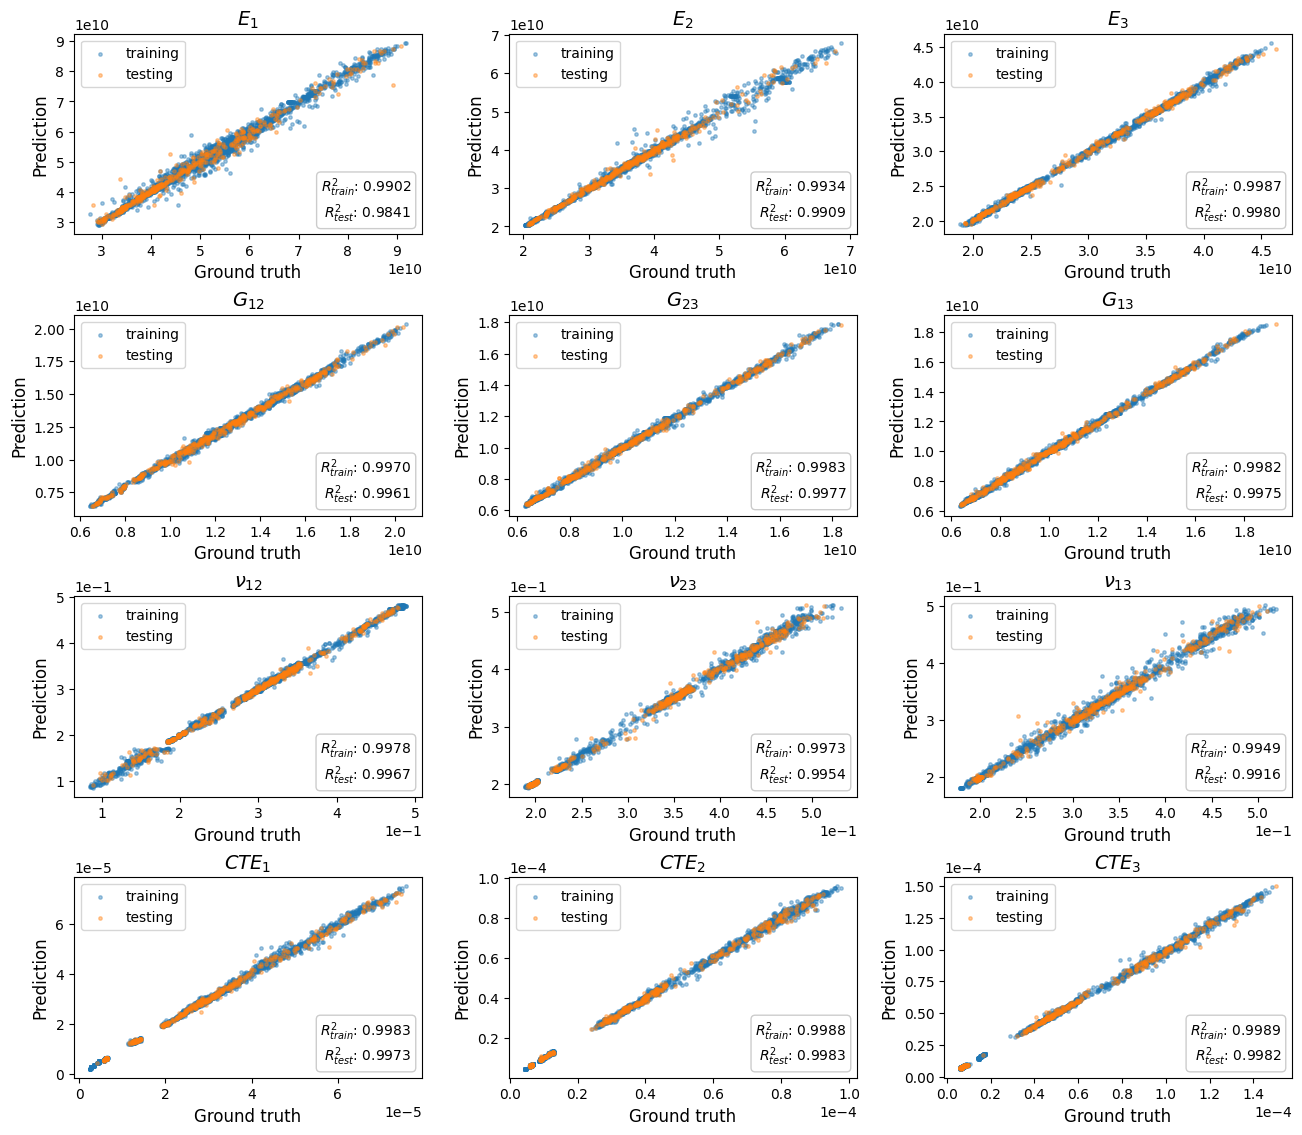

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import r2_score  # 新增：匯入 R2 分數計算模組

# 1. 建立具有下標的標題清單 (使用 LaTeX 語法)
formatted_titles = [
    r'$E_1$', r'$E_2$', r'$E_3$',
    r'$G_{12}$', r'$G_{23}$', r'$G_{13}$',
    r'$\nu_{12}$', r'$\nu_{23}$', r'$\nu_{13}$',
    r'$CTE_1$', r'$CTE_2$', r'$CTE_3$'
]

fig, ax = plt.subplots(4, 3, figsize=(14, 12))
i = 0

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        # 繪製散佈圖
        ax[a, b].scatter(y_train_inverse[:, i], y_pred_inverse[:, i], s=6, alpha=0.4)
        ax[a, b].scatter(y_test_inverse[:, i], y_pred_test_inverse[:, i], s=6, alpha=0.4)
        
        # 設定標題與軸標籤
        ax[a, b].set_title(formatted_titles[i], fontsize=14)
        ax[a, b].set_xlabel('Ground truth', fontsize=12)
        ax[a, b].set_ylabel('Prediction', fontsize=12)
        
        # 強制使用科學記號
        ax[a, b].ticklabel_format(style='sci', scilimits=(0, 0), axis='both')
        ax[a, b].legend(['training', 'testing'], loc='upper left', fontsize=10)
        
        # ==========================================================
        # 新增：計算 R2 分數並在右下角加上文字方塊
        # ==========================================================
        r2_train = r2_score(y_train_inverse[:, i], y_pred_inverse[:, i])
        r2_test = r2_score(y_test_inverse[:, i], y_pred_test_inverse[:, i])
        
        # 設定要顯示的文字內容 (包含 LaTeX 格式的 R^2)
        text_str = f'$R^2_{{train}}$: {r2_train:.4f}\n$R^2_{{test}}$: {r2_test:.4f}'
        
        # 使用 transform=ax[a, b].transAxes 讓座標 (0.95, 0.05) 對齊右下角
        # bbox 參數加入白底與些微透明度，避免文字與資料點重疊導致難以辨識
        ax[a, b].text(0.97, 0.05, text_str, transform=ax[a, b].transAxes, 
                      fontsize=10, verticalalignment='bottom', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))
        # ==========================================================
        
        i = i + 1

# 控制圖表間距
plt.subplots_adjust(left=0.08, right=0.95, bottom=0.08, top=0.95, wspace=0.25, hspace=0.4)
plt.savefig("effective_modulus_results.png", dpi=400)

plt.show()

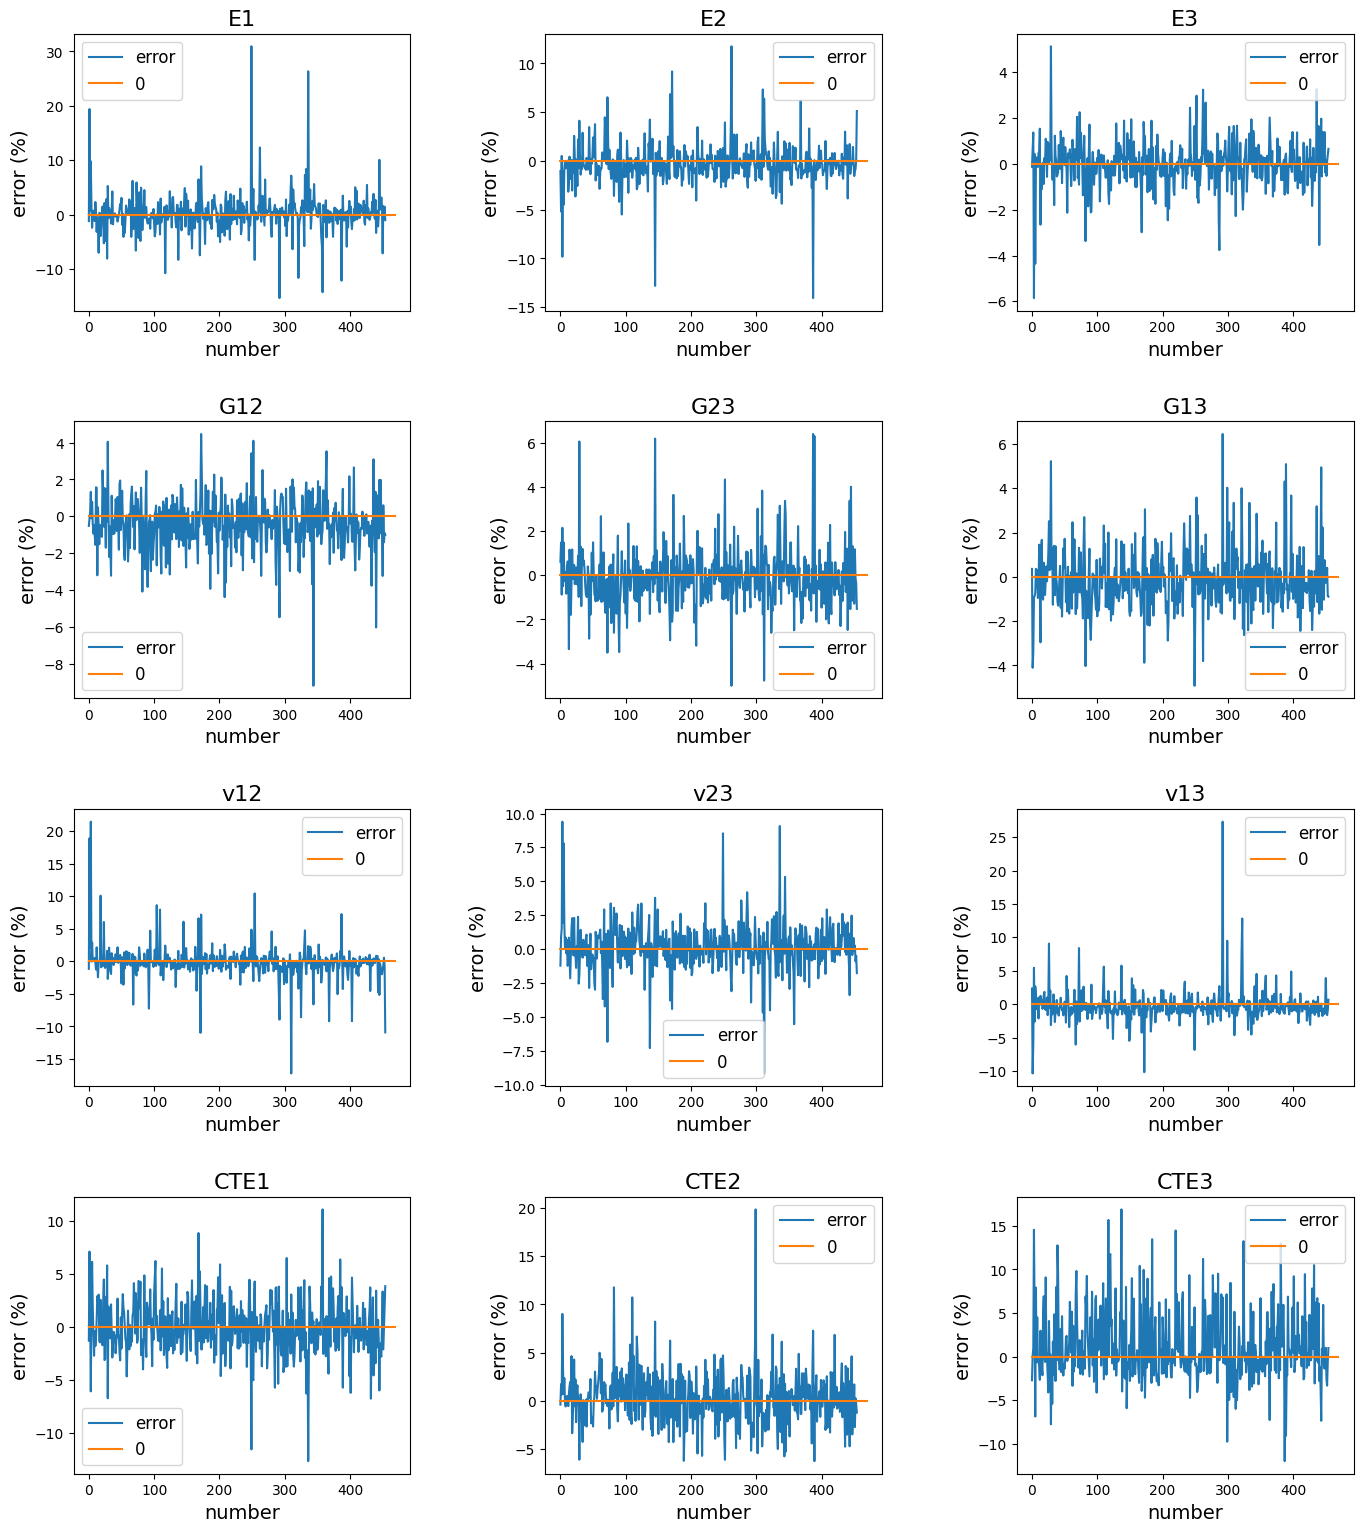

In [39]:
# 將每項output的誤差百分比圖像化(test)

fig, ax = plt.subplots(4, 3)
i=0

for a in range(len(ax)): 
    for b in range(len(ax[a])):
        error = ((y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i])*100
        ax[a, b].plot(error)
        ax[a, b].plot(np.linspace(0,0,470))
        ax[a, b].set_title(output_title[i], fontsize=16)
        ax[a, b].set_xlabel('number', fontsize=14)
        ax[a, b].set_ylabel('error (%)', fontsize=14)
        ax[a, b].legend(['error', '0'], fontsize=12)
        i=i+1

plt.subplots_adjust(left=0, bottom=0, right=2, top=3, wspace=0.4, hspace=0.4)
plt.show()

In [40]:
# test:找出每項output最大、最小、平均的誤差以及發生最大誤差時的數值比較

for i in range(0,12):
    error = abs(y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i]
    avg_error = sum(abs(y_pred_test_inverse.T[i] - y_test_inverse.T[i])/y_test_inverse.T[i])/y_pred_test.shape[0]
    print(str(output_title[i]), 'error avg : {:.3%}'.format(avg_error))
    print(str(output_title[i]), 'error min : {:.5%}'.format(min(error)))
    print(str(output_title[i]), 'error max : {:.3%}'.format(max(error)))
    
    error = error.tolist()
    print('The index of maximum error : %d' % error.index(max(error)))
    print(str(output_title[i]), 'pred', error.index(max(error)), ': %3.3e' % y_pred_test_inverse.T[i, error.index(max(error))])
    print(str(output_title[i]), 'test', error.index(max(error)), ': %3.3e' % y_test_inverse.T[i, error.index(max(error))])
    print('----------')

E1 error avg : 2.074%
E1 error min : 0.00076%
E1 error max : 30.954%
The index of maximum error : 249
E1 pred 249 : 4.427e+10
E1 test 249 : 3.380e+10
----------
E2 error avg : 1.323%
E2 error min : 0.00638%
E2 error max : 14.056%
The index of maximum error : 387
E2 pred 387 : 3.381e+10
E2 test 387 : 3.934e+10
----------
E3 error avg : 0.693%
E3 error min : 0.00068%
E3 error max : 5.856%
The index of maximum error : 3
E3 pred 3 : 2.365e+10
E3 test 3 : 2.512e+10
----------
G12 error avg : 1.119%
G12 error min : 0.00239%
G12 error max : 9.191%
The index of maximum error : 344
G12 pred 344 : 9.835e+09
G12 test 344 : 1.083e+10
----------
G23 error avg : 0.924%
G23 error min : 0.00278%
G23 error max : 6.390%
The index of maximum error : 387
G23 pred 387 : 8.084e+09
G23 test 387 : 7.598e+09
----------
G13 error avg : 1.010%
G13 error min : 0.00043%
G13 error max : 6.457%
The index of maximum error : 292
G13 pred 292 : 1.123e+10
G13 test 292 : 1.055e+10
----------
v12 error avg : 1.387%
v12 er

In [41]:
# train:找出每項output最大、最小、平均的誤差以及發生最大誤差時的數值比較

for i in range(0,12):
    error = abs(y_pred_inverse.T[i] - y_train_inverse.T[i])/y_train_inverse.T[i]
    avg_error = sum(abs(y_pred_inverse.T[i] - y_train_inverse.T[i])/y_train_inverse.T[i])/y_pred.shape[0]
    print(str(output_title[i]), 'error avg : {:.3%}'.format(avg_error))
    print(str(output_title[i]), 'error min : {:.5%}'.format(min(error)))
    print(str(output_title[i]), 'error max : {:.3%}'.format(max(error)))
    
    error = error.tolist()
    print('The index of maximum error : %d' % error.index(max(error)))
    print(str(output_title[i]), 'pred', error.index(max(error)), ': %3.3e' % y_pred_inverse.T[i, error.index(max(error))])
    print(str(output_title[i]), 'test', error.index(max(error)), ': %3.3e' % y_train_inverse.T[i, error.index(max(error))])
    print('----------')

E1 error avg : 1.656%
E1 error min : 0.00162%
E1 error max : 22.404%
The index of maximum error : 1534
E1 pred 1534 : 5.894e+10
E1 test 1534 : 4.816e+10
----------
E2 error avg : 1.142%
E2 error min : 0.00023%
E2 error max : 22.865%
The index of maximum error : 1342
E2 pred 1342 : 4.548e+10
E2 test 1342 : 3.702e+10
----------
E3 error avg : 0.594%
E3 error min : 0.00030%
E3 error max : 8.890%
The index of maximum error : 2066
E3 pred 2066 : 2.515e+10
E3 test 2066 : 2.760e+10
----------
G12 error avg : 0.981%
G12 error min : 0.00197%
G12 error max : 9.224%
The index of maximum error : 1534
G12 pred 1534 : 1.161e+10
G12 test 1534 : 1.063e+10
----------
G23 error avg : 0.816%
G23 error min : 0.00002%
G23 error max : 7.084%
The index of maximum error : 2066
G23 pred 2066 : 1.142e+10
G23 test 2066 : 1.229e+10
----------
G13 error avg : 0.878%
G13 error min : 0.00102%
G13 error max : 7.223%
The index of maximum error : 879
G13 pred 879 : 7.478e+09
G13 test 879 : 6.974e+09
----------
v12 erro

In [42]:
# 定義 R-squared function

def polyfit(x, y, degree):
    results = {}

    coeffs = np.polyfit(x, y, degree)
     # Polynomial Coefficients
    results['polynomial'] = coeffs.tolist()

    correlation = np.corrcoef(x, y)[0,1]
    

     # r
    results['correlation'] = correlation
     # r-squared
    results['determination'] = correlation**2

    return results

In [43]:
# 查看每項output的 R-squared

degree = 1

for i in range(0,12):
    print(str(output_title[i]), polyfit(y_test_inverse[i], y_pred_test_inverse[i], degree))

E1 {'polynomial': [0.9884174978743123, 49807163.89615354], 'correlation': np.float64(0.9999929507114549), 'determination': np.float64(0.9999859014726022)}
E2 {'polynomial': [1.042639423835253, -75301030.01134829], 'correlation': np.float64(0.9912854406535085), 'determination': np.float64(0.9826468248516206)}
E3 {'polynomial': [1.0070468341582666, -38118660.80608905], 'correlation': np.float64(0.999984421370602), 'determination': np.float64(0.9999688429838975)}
G12 {'polynomial': [0.9729989478078568, 130630748.02718836], 'correlation': np.float64(0.9938779152335828), 'determination': np.float64(0.9877933103890528)}
G23 {'polynomial': [1.0106838943788181, -85766512.63330865], 'correlation': np.float64(0.9999409945578558), 'determination': np.float64(0.9998819925973538)}
G13 {'polynomial': [0.96456049948336, 100612837.07443373], 'correlation': np.float64(0.9998012910737223), 'determination': np.float64(0.999602621632682)}
v12 {'polynomial': [0.998280924680404, -4922908.555049665], 'correl

## 不同模型基準測試

### --- MLP model ---

In [44]:
import torch
import torch.nn as nn

class FlattenedMLP(nn.Module):
    def __init__(self, img_elements=25, info_features=21, out_features=12):
        super(FlattenedMLP, self).__init__()
        
        # 5x5 矩陣攤平為 25，加上 21 個數值特徵，總輸入維度為 46
        in_features = img_elements + info_features
        
        # 使用與原本 Dual-Stage 融合後相似的 Dense Layer 架構以確保參數規模公平
        self.mlp = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, out_features)
        )

    def forward(self, x_img, x_info):
        # x_img shape 預期為 (batch_size, 1, 5, 5) 或 (batch_size, 5, 5)
        # 保持 batch_size 維度，將影像矩陣攤平
        x_img_flat = x_img.view(x_img.size(0), -1) 
        
        # 將攤平的影像特徵與數值特徵在特徵維度(dim=1)合併
        x_combined = torch.cat((x_img_flat, x_info), dim=1)
        
        # 通過純多層感知機
        out = self.mlp(x_combined)
        return out


In [ ]:
import time
import torch
import torch.nn as nn

# 設定訓練參數
epochs = 3000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 初始化模型、優化器、損失函數
# 注意：這裡改用基準比較的 FlattenedMLP
model = FlattenedMLP().to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, eps=1e-7) 
criterion = nn.MSELoss() 

# 初始化早停物件 (假設 EarlyStopper 已經在前面定義好)
early_stopper = EarlyStopper(patience=100)

# 開始計時
start = time.time()
print("Training started...")

# 變數名稱加上 mlp 區分
history_mlp = {'loss': [], 'val_loss': []} 

for epoch in range(epochs):
    # - 訓練階段 (Training) -
    model.train()
    running_loss = 0.0
    for img_batch, info_batch, target_batch in train_loader:
        # 搬移數據到 GPU
        img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
        
        # 1. 歸零梯度
        optimizer.zero_grad()
        
        # 2. 前向傳播
        # FlattenedMLP 內部會自動把 img_batch 攤平並與 info_batch 合併，所以這裡直接傳入即可
        outputs = model(img_batch, info_batch)
        
        # 3. 計算 Loss
        loss = criterion(outputs, target_batch)
        
        # 4. 反向傳播
        loss.backward()
        
        # 5. 更新權重
        optimizer.step()
        
        running_loss += loss.item() * img_batch.size(0) # 累加 Loss
    
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # - 驗證階段 (Validation) -
    model.eval()
    val_running_loss = 0.0
    with torch.no_grad(): # 驗證時不需要計算梯度，節省記憶體
        for img_batch, info_batch, target_batch in val_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            val_running_loss += loss.item() * img_batch.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    
    # - 紀錄與印出 -
    history_mlp['loss'].append(epoch_loss)
    history_mlp['val_loss'].append(epoch_val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
    
    # - 檢查早停與存檔 -
    if early_stopper.early_stop(epoch_val_loss, model):
        print("Early stopping triggered!")
        break

# 恢復最佳權重
early_stopper.load_best_weights(model)

# 最終存檔 (修改存檔檔名避免覆蓋原本的模型)
# torch.save(model.state_dict(), 'baseline_mlp_model.pth')

end = time.time()
print('Training has finished')
print('spend time is : ', end-start)

Using device: cuda
Training started...
Epoch 1/3000 - loss: 0.098649 - val_loss: 0.047774
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 2/3000 - loss: 0.043609 - val_loss: 0.034484
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 3/3000 - loss: 0.030790 - val_loss: 0.023200
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 4/3000 - loss: 0.020003 - val_loss: 0.016109
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 5/3000 - loss: 0.014827 - val_loss: 0.012453
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 6/3000 - loss: 0.011285 - val_loss: 0.009125
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 7/3000 - loss: 0.008197 - val_loss: 0.007886
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 8/3000 - loss: 0.007075 - val_loss: 0.005790
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 9/3000 - loss: 0.005617 - val_loss: 0.004924
  [Checkpoint] Validation Loss Improved. Model Saved.
Epoch 10/3000 - 

In [46]:
import numpy as np
import torch
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 確保已經建立獨立測試集的 DataLoader
# (假設已透過 test_dataset = DualInputDataset(x_test_img, x_test_data_scaled, y_test_data_scaled) 建立)
# test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
# ==========================================

# 將模型切換至評估模式
model.eval()

# 用來儲存所有批次的預測結果與真實標籤
all_predictions = []
all_ground_truth = []

print("開始進行 Flattened MLP 模型於【獨立測試集】的評估與指標計算...")

# 測試階段不需要計算梯度
with torch.no_grad(): 
    # 修改重點：將 val_loader 改為 test_loader
    for img_batch, info_batch, target_batch in test_loader:
        # 將輸入數據移至指定裝置 (GPU 或 CPU)
        img_batch, info_batch = img_batch.to(device), info_batch.to(device)
        
        # 前向傳播計算預測值
        outputs = model(img_batch, info_batch)
        
        # 將預測結果與真實值移回 CPU 並轉換為 NumPy 陣列
        all_predictions.append(outputs.cpu().numpy())
        all_ground_truth.append(target_batch.cpu().numpy())

# 將所有批次的數據垂直堆疊，還原成完整的矩陣格式
all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

# ==========================================
# 進行反正規化還原 (Inverse Transform)
# ==========================================
# 將預測值與真實標籤還原回真實物理尺度
all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

# ==========================================
# 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================

# 1. 計算 決定係數 (R2 Score)
mlp_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)

# 2. 計算 平均絕對誤差 (MAE)
mlp_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)

# 3. 計算 平均相對誤差 (MRE)
# 加上 1e-8 的 epsilon 是為了防止分母可能為零的除錯機制，確保計算數值穩定
epsilon = 1e-8
mlp_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n" + "="*50)
print("[Flattened MLP 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]")
print(f"整體 R2 Score: {mlp_r2:.4f}")
print(f"整體 MAE: {mlp_mae:.4f}") 
print(f"整體 平均相對誤差 (MRE): {mlp_mre:.2f}%")
print("="*50)

開始進行 Flattened MLP 模型於【獨立測試集】的評估與指標計算...

[Flattened MLP 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]
整體 R2 Score: 0.9784
整體 MAE: 445108768.0000
整體 平均相對誤差 (MRE): 3.50%


### --- RandomForest model ---

In [47]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 步驟 1：資料格式轉換與攤平
# ==========================================
# 處理訓練集：修改為使用「完整擴充並縮放後」的訓練集
X_img_train_flat = x_train_image_expanded.reshape(x_train_image_expanded.shape[0], -1)
X_train_ml = np.concatenate((X_img_train_flat, x_train_data_scaled), axis=1)

# 處理測試集：修改為使用未曾參與訓練的「獨立測試集」
X_img_test_flat = x_test_img.reshape(x_test_img.shape[0], -1)
X_test_ml = np.concatenate((X_img_test_flat, x_test_data_scaled), axis=1)

# 更新標籤變數
y_train_ml = y_train_data_scaled
y_test_ml = y_test_data_scaled

# ==========================================
# 步驟 2：訓練 Random Forest (隨機森林)
# ==========================================
print("開始訓練 Random Forest...")
rf_model = RandomForestRegressor(n_estimators=3, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ml, y_train_ml)

# 修改重點：改為預測獨立測試集
rf_preds = rf_model.predict(X_test_ml)

# ==========================================
# 步驟 3：進行反正規化還原 (Inverse Transform)
# ==========================================
# 修改重點：將「測試集」真實標籤與隨機森林預測值還原回真實物理尺度
y_test_ml_inv = Y_minMax.inverse_transform(y_test_ml)
rf_preds_inv = Y_minMax.inverse_transform(rf_preds)

# ==========================================
# 步驟 4：核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================
# 計算決定係數 (R2 Score)
rf_r2 = r2_score(y_test_ml_inv, rf_preds_inv)

# 計算平均絕對誤差 (MAE)
rf_mae = mean_absolute_error(y_test_ml_inv, rf_preds_inv)

# 計算平均相對誤差 (MRE)
# 加上 1e-8 防止分母為零
epsilon = 1e-8
rf_mre = np.mean(np.abs((y_test_ml_inv - rf_preds_inv) / (y_test_ml_inv + epsilon))) * 100 

print("\n" + "="*50)
print(f"[Random Forest 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]")
print(f"整體 R2 Score: {rf_r2:.4f}")
print(f"整體 MAE: {rf_mae:.4f}")
print(f"整體 平均相對誤差 (MRE): {rf_mre:.2f}%")
print("="*50)

開始訓練 Random Forest...

[Random Forest 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]
整體 R2 Score: 0.9759
整體 MAE: 445022056.5550
整體 平均相對誤差 (MRE): 3.07%


### --- XGBoost ---

In [48]:
# ==========================================
# 步驟 3：訓練 XGBoost
# ==========================================
print("\n開始訓練 XGBoost...")
# XGBoost 預設只支援單一輸出，必須包裝進 MultiOutputRegressor
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model = MultiOutputRegressor(xgb_base)

# 使用完整擴充並縮放後的訓練集進行訓練
xgb_model.fit(X_train_ml, y_train_ml)

# 修改重點：改為預測未曾參與訓練的獨立測試集
xgb_preds = xgb_model.predict(X_test_ml)

# ==========================================
# 進行反正規化還原 (Inverse Transform)
# ==========================================
xgb_preds_inv = Y_minMax.inverse_transform(xgb_preds)

# ==========================================
# 核心指標計算 (基於還原後的 12 個彈性常數)
# ==========================================
# 修改重點：使用測試集真實標籤 y_test_ml_inv 進行計算 (此變數在前面的 Random Forest 步驟中已定義)
xgb_r2 = r2_score(y_test_ml_inv, xgb_preds_inv)
xgb_mae = mean_absolute_error(y_test_ml_inv, xgb_preds_inv)
xgb_mre = np.mean(np.abs((y_test_ml_inv - xgb_preds_inv) / (y_test_ml_inv + epsilon))) * 100

# ==========================================
# 印出評估結果
# ==========================================
print("\n" + "="*50)
print(f"[XGBoost 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]")
print(f"整體 R2 Score: {xgb_r2:.4f}")
print(f"整體 MAE: {xgb_mae:.4f}")
print(f"整體 平均相對誤差 (MRE): {xgb_mre:.2f}%")
print("="*50)


開始訓練 XGBoost...

[XGBoost 線彈性模型評估結果 - 獨立測試集 (Unseen Test Set)]
整體 R2 Score: 0.9887
整體 MAE: 307708557.0239
整體 平均相對誤差 (MRE): 2.30%


## 不同資料分割集測試

In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 0. 基礎設定與獨立測試集準備
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
epochs = 3000
k_folds = 5

# 定義雙輸入資料集
class DualInputDataset(Dataset):
    def __init__(self, images, infos, targets):
        self.images = torch.tensor(images, dtype=torch.float32)
        self.infos = torch.tensor(infos, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.images[idx], self.infos[idx], self.targets[idx]

# 建立獨立測試集的 DataLoader (這部分不需要折疊，拉到迴圈外建立一次即可)
test_dataset = DualInputDataset(x_test_img, x_test_data_scaled, y_test_data_scaled)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(f"獨立測試集數量: {len(test_dataset)}")

# ==========================================
# 1. 準備 K-Fold 分割器
# ==========================================
# 使用 KFold，確保每次切分都有隨機性且互不重疊
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

# 用來記錄 5 個 Fold 在獨立測試集上的表現
fold_metrics = {'r2': [], 'mae': [], 'mre': []}

# 開始進行 5-Fold 交叉驗證迴圈
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train_image_expanded)):
    print("\n" + "="*50)
    print(f"開始執行 Fold {fold + 1} / {k_folds}")
    print("="*50)

    # --- 1.1 切分該 Fold 的訓練與驗證資料 ---
    # 利用 KFold 產生的 index 來對 numpy array 進行切片
    X_img_train, X_img_val = x_train_image_expanded[train_idx], x_train_image_expanded[val_idx]
    X_info_train, X_info_val = x_train_data_scaled[train_idx], x_train_data_scaled[val_idx]
    y_train, y_val = y_train_data_scaled[train_idx], y_train_data_scaled[val_idx]

    # 建立 Dataset & DataLoader
    train_dataset = DualInputDataset(X_img_train, X_info_train, y_train)
    val_dataset = DualInputDataset(X_img_val, X_info_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # --- 1.2 重置模型與優化器 (極度重要) ---
    # 必須在迴圈內初始化，否則會延續上一個 Fold 訓練好的權重
    model = CompositeDualModel().to(device) 
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7)
    criterion = nn.MSELoss()
    early_stopper = EarlyStopper(patience=100)

    # --- 1.3 訓練階段 ---
    start = time.time()
    history = {'loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for img_batch, info_batch, target_batch in train_loader:
            img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(img_batch, info_batch)
            loss = criterion(outputs, target_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * img_batch.size(0)
        
        epoch_loss = running_loss / len(train_loader.dataset)
        
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for img_batch, info_batch, target_batch in val_loader:
                img_batch, info_batch, target_batch = img_batch.to(device), info_batch.to(device), target_batch.to(device)
                outputs = model(img_batch, info_batch)
                loss = criterion(outputs, target_batch)
                val_running_loss += loss.item() * img_batch.size(0)
                
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        
        # 為了避免洗頻，這裡設定每 100 epoch 印一次，你可以視需求調整
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Fold {fold+1} - Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f} - val_loss: {epoch_val_loss:.6f}")
        
        if early_stopper.early_stop(epoch_val_loss, model):
            print(f"Fold {fold+1}: Early stopping triggered at Epoch {epoch+1}!")
            break

    # 恢復該 Fold 最佳權重並存檔 (檔名加上 fold 標籤避免被覆蓋)
    early_stopper.load_best_weights(model)
    torch.save(model.state_dict(), f'effective_model_pytorch_fold{fold+1}.pth')
    print(f'Fold {fold+1} Training spend time: {time.time()-start:.2f} s')

    # --- 1.4 獨立測試集評估 ---
    # 利用剛剛訓練好的 Fold 最佳模型，預測獨立測試集
    model.eval()
    all_predictions = []
    all_ground_truth = []
    
    with torch.no_grad(): 
        for img_batch, info_batch, target_batch in test_loader:
            img_batch, info_batch = img_batch.to(device), info_batch.to(device)
            outputs = model(img_batch, info_batch)
            all_predictions.append(outputs.cpu().numpy())
            all_ground_truth.append(target_batch.cpu().numpy())

    all_predictions = np.vstack(all_predictions)
    all_ground_truth = np.vstack(all_ground_truth)

    # 反正規化
    all_ground_truth_inv = Y_minMax.inverse_transform(all_ground_truth)
    all_predictions_inv = Y_minMax.inverse_transform(all_predictions)

    # 計算該 Fold 的指標
    epsilon = 1e-8
    fold_r2 = r2_score(all_ground_truth_inv, all_predictions_inv)
    fold_mae = mean_absolute_error(all_ground_truth_inv, all_predictions_inv)
    fold_mre = np.mean(np.abs((all_ground_truth_inv - all_predictions_inv) / (all_ground_truth_inv + epsilon))) * 100
    
    fold_metrics['r2'].append(fold_r2)
    fold_metrics['mae'].append(fold_mae)
    fold_metrics['mre'].append(fold_mre)

    print(f"[Fold {fold+1} 測試集結果] R2: {fold_r2:.4f}, MAE: {fold_mae:.4f}, MRE: {fold_mre:.2f}%")

Using device: cuda
獨立測試集數量: 455

開始執行 Fold 1 / 5
Fold 1 - Epoch 1/3000 - loss: 0.138336 - val_loss: 0.073068
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation Loss Improved. Model Saved.
  [Checkpoint] Validation L

In [72]:
fold_metrics['r2']

[0.995888888835907,
 0.9955665469169617,
 0.9954878687858582,
 0.9951205253601074,
 0.9957640767097473]

In [71]:
# ==========================================
# 2. 總結 5-Fold 交叉驗證結果
# ==========================================
print("\n" + "="*50)
print("[5-Fold Cross-Validation 最終評估結果 (獨立測試集)]")
print(f"平均 R2 Score: {np.mean(fold_metrics['r2']):.4f} ± {np.std(fold_metrics['r2']):.4f}")
print(f"平均 MAE: {np.mean(fold_metrics['mae']):.4f} ± {np.std(fold_metrics['mae']):.4f}") 
print(f"平均 MRE: {np.mean(fold_metrics['mre']):.2f}% ± {np.std(fold_metrics['mre']):.2f}%")
print("="*50)


[5-Fold Cross-Validation 最終評估結果 (獨立測試集)]
平均 R2 Score: 0.9956 ± 0.0003
平均 MAE: 158104160.0000 ± 7935805.9242
平均 MRE: 1.32% ± 0.10%
